In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:2f}'.format)

In [7]:
url='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df=pd.read_csv(url)

In [8]:
df.shape

(891, 12)

In [10]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.283300,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.100000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.050000,NaN,S


In [11]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.250000,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.283300,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.925000,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.100000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.050000,NaN,S


In [14]:
df.Pclass.dtype

dtype('int64')

In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# for unique values in code:

In [25]:
for  i in df.columns:
    print(i, df[i].nunique())

PassengerId 891
Survived 2
Pclass 3
Name 891
Sex 2
Age 88
SibSp 7
Parch 7
Ticket 681
Fare 248
Cabin 147
Embarked 3


In [ ]:
# drop unncessary columns

In [65]:
df.drop('PassengerId', axis=1, inplace=True)

In [67]:
df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [74]:
cat_fea=['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

In [75]:
cont_fea=['Age', 'Fare']

In [76]:
# cardianality code

In [77]:
for i in cat_fea:
    print(i, df[i].nunique())

Pclass 3
Sex 2
SibSp 7
Parch 7
Embarked 3


In [ ]:
# summary table

In [82]:
summary_table=pd.DataFrame({
    'Feature': df.columns,
    'datatype': df.dtypes.values,
    'missing': df.isnull().sum().values,
    'unique' : df.nunique().values
        })
    

In [83]:
summary_table

,Feature,datatype,missing,unique
0,Survived,int64,0,2
1,Pclass,int64,0,3
2,Sex,object,0,2
3,Age,float64,177,88
4,SibSp,int64,0,7
5,Parch,int64,0,7
6,Fare,float64,0,248
7,Embarked,object,2,3


In [84]:
# Handling missing value

In [85]:
df['Age'].describe()

count   714.000000
mean     29.699118
std      14.526497
min       0.420000
25%      20.125000
50%      28.000000
75%      38.000000
max      80.000000
Name: Age, dtype: float64

In [86]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [89]:
df['Age']=df['Age'].fillna(df['Age'].median())

<Axes: >

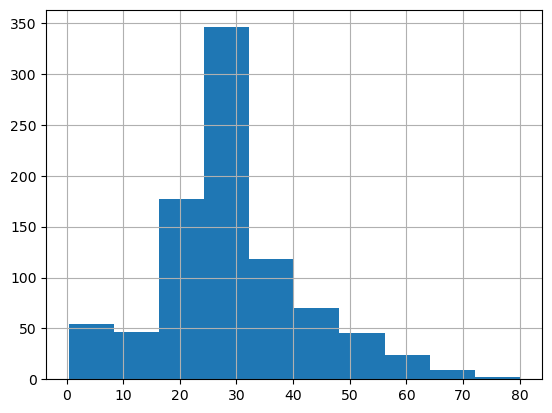

In [90]:
df['Age'].hist()

<Axes: >

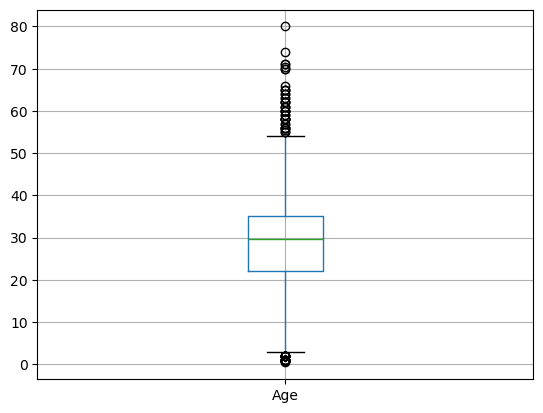

In [91]:
df.boxplot(column='Age')

In [92]:
# handle Embarked

In [93]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode())

In [94]:
# handling fare

<Axes: >

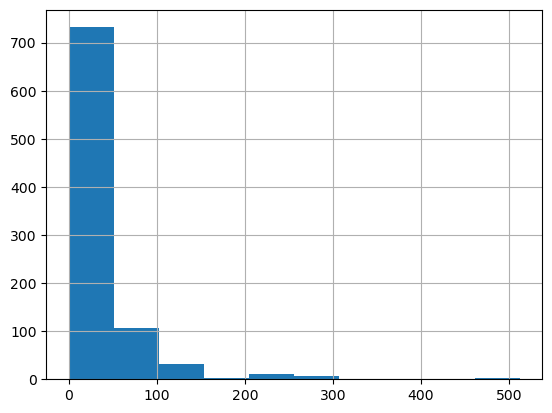

In [95]:
df['Fare'].hist()

<Axes: >

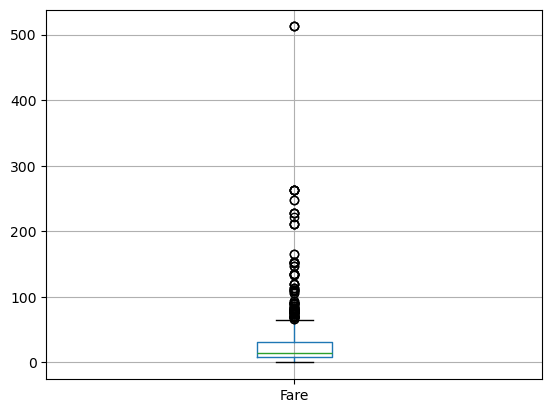

In [97]:
df.boxplot('Fare')

In [98]:
df['Fare'].skew()

np.float64(4.787316519674893)

In [104]:
df['Fare']=np.log1p(df['Fare'])

In [105]:
df['Fare'].skew()

np.float64(0.3949280095189306)

In [108]:
df.drop('fare_log', axis=1, inplace=True)

In [109]:
# handling sex catagorical column

In [112]:
from sklearn.preprocessing import LabelEncoder
lbl=LabelEncoder()
df['Sex']=lbl.fit_transform(df['Sex'])

In [113]:
# Embarked column

In [114]:
df=pd.get_dummies(df, columns=['Embarked'])

In [115]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.000000,1,0,2.110213,False,False,True
1,1,1,0,38.000000,1,0,4.280593,True,False,False
2,1,3,0,26.000000,0,0,2.188856,False,False,True
3,1,1,0,35.000000,1,0,3.990834,False,False,True
4,0,3,1,35.000000,0,0,2.202765,False,False,True


In [116]:
# with pclass

In [117]:
df=pd.get_dummies(df, columns=['Pclass'])

In [118]:
df.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,1,22.000000,1,0,2.110213,False,False,True,False,False,True
1,1,0,38.000000,1,0,4.280593,True,False,False,True,False,False
2,1,0,26.000000,0,0,2.188856,False,False,True,False,False,True
3,1,0,35.000000,1,0,3.990834,False,False,True,True,False,False
4,0,1,35.000000,0,0,2.202765,False,False,True,False,False,True


In [ ]:
# dummy columns data types

In [119]:
dummy_cols = ['Embarked_C', 'Embarked_Q', 'Embarked_S',
              'Pclass_1', 'Pclass_2', 'Pclass_3']
df[dummy_cols] = df[dummy_cols].astype(int)
print("Dtypes fixed ✓")
df.head()

Dtypes fixed ✓


,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,1,22.000000,1,0,2.110213,0,0,1,0,0,1
1,1,0,38.000000,1,0,4.280593,1,0,0,1,0,0
2,1,0,26.000000,0,0,2.188856,0,0,1,0,0,1
3,1,0,35.000000,1,0,3.990834,0,0,1,1,0,0
4,0,1,35.000000,0,0,2.202765,0,0,1,0,0,1


In [121]:
# New columns extraction

In [120]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']   = (df['FamilySize'] == 1).astype(int)
df['AgeGroup']  = pd.cut(df['Age'],
                          bins=[0,12,18,35,60,100],
                          labels=[0,1,2,3,4]).astype(int)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
print("New features added ✓")
print(df[['FamilySize','IsAlone','AgeGroup','FarePerPerson']].head())


New features added ✓
   FamilySize  IsAlone  AgeGroup  FarePerPerson
0           2        0         2       1.055107
1           2        0         3       2.140297
2           1        1         2       2.188856
3           2        0         2       1.995417
4           1        1         2       2.202765


In [122]:
# visualizations

In [123]:
import os

os.makedirs('plots', exist_ok=True)

C:\Users\Dr.Sahib\AppData\Local\Temp\ipykernel_26500\2187325543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(x='Sex', y='Survived', data=df, palette='Blues')


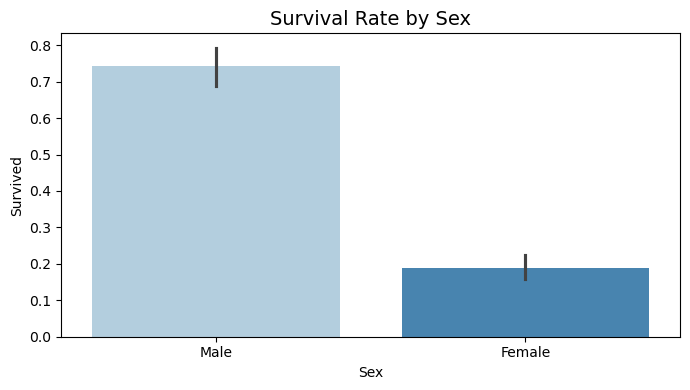

In [126]:
# Plot 1: Survival by Sex
plt.figure(figsize=(7,4))
sn.barplot(x='Sex', y='Survived', data=df, palette='Blues')
plt.title('Survival Rate by Sex', fontsize=14)
plt.xticks([0,1],['Male','Female'])
plt.tight_layout()
plt.savefig('plots/plot1_survival_by_sex.png', dpi=150)
plt.show()

In [127]:
# Plot 2: Age distribution by survival

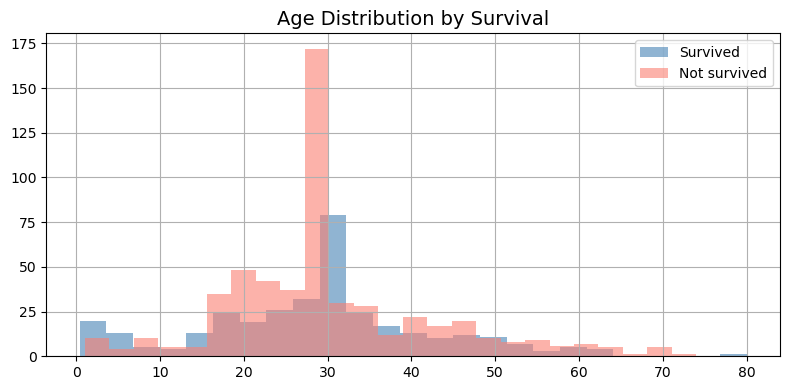

In [128]:
plt.figure(figsize=(8,4))
df[df['Survived']==1]['Age'].hist(alpha=0.6,bins=25,label='Survived',color='steelblue')
df[df['Survived']==0]['Age'].hist(alpha=0.6,bins=25,label='Not survived',color='salmon')
plt.legend(); plt.title('Age Distribution by Survival',fontsize=14)
plt.tight_layout()
plt.savefig('plots/plot2_age_distribution.png', dpi=150)
plt.show()

In [129]:
# Plot 3: Correlation heatmap

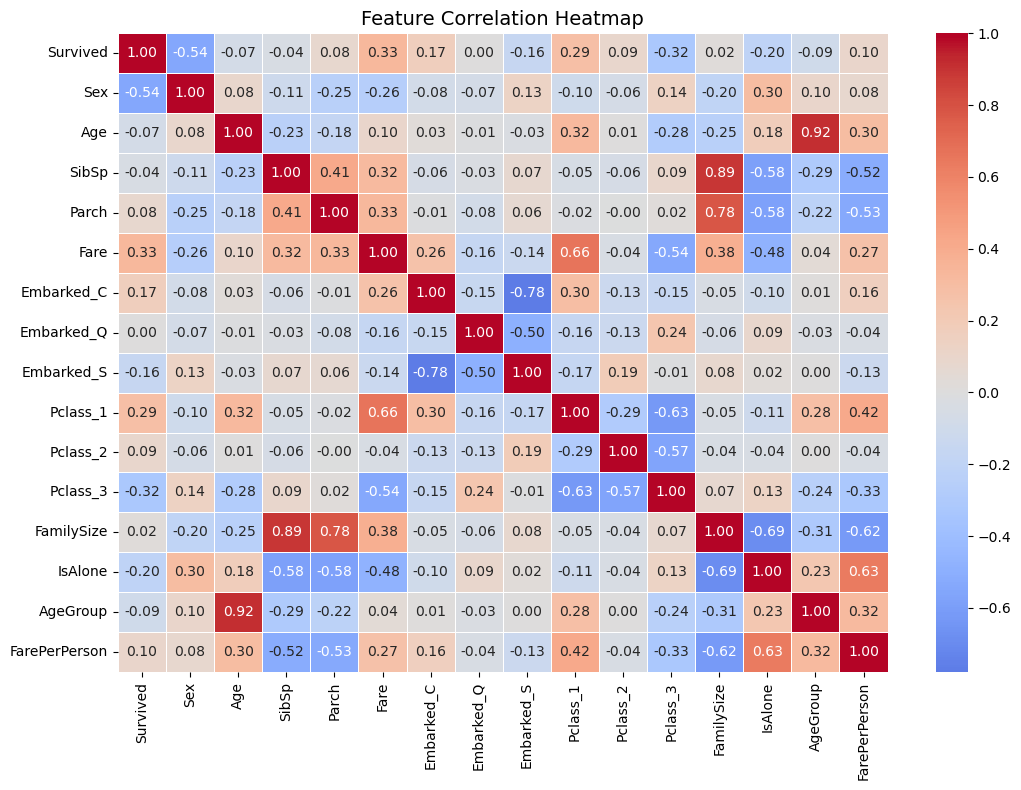

All 3 plots saved ✓


In [130]:
plt.figure(figsize=(11,8))
sn.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap',fontsize=14)
plt.tight_layout()
plt.savefig('plots/plot3_correlation_heatmap.png', dpi=150)
plt.show()
print("All 3 plots saved ✓")

In [131]:
# FIX 4 — Save cleaned dataset

In [132]:
os.makedirs('data', exist_ok=True)
df.to_csv('data/titanic_clean.csv', index=False)
print("Saved! Final shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Total nulls:", df.isnull().sum().sum())

Saved! Final shape: (891, 16)
Columns: ['Survived', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson']
Total nulls: 0
